# Post-BBN radioactive-decay evolution (the "Decay Time" / DT era)

Standard BBN integration stops at `T_end = 0.001 MeV`, i.e. cosmic time
`t_end ≈ 1.3×10⁶ s ≈ 15 days`.  At that point several nuclides are still
radioactive and keep decaying for years to millions of years, long after all
thermonuclear reactions have frozen out.  The **DT era** (DECAY.md §4)
propagates the abundance vector forward under the *constant* decay matrix `D`,

$$\frac{dY}{dt} = D\,Y \quad\Longrightarrow\quad Y(t) = \exp\!\big(D\,(t-t_{\rm end})\big)\,Y(t_{\rm end}),$$

solved exactly with `scipy.linalg.expm` (robust to the ~16-decade spread of
decay constants, from B15 at T½ ≈ 10 ms to Be10 at T½ ≈ 1.39 Myr).

This notebook runs the **large** network with `decay_era=True` and plots
`Y(t)` for every tracked nuclide from ~1 s out to `t_end + 1 Gyr`.  When
`decay_era=True`, the public abundance interpolator is extended across the
LT→DT boundary, so `run[species](t)` (and `get_quantity(..., t=...)`) return a
single seamless history — exactly like the HT→MT→LT concatenation during BBN —
with no need to stitch eras together by hand.  The visually obvious features
are the decay "steps":

| Decay | T½ | becomes visible near |
|-------|----|----------------------|
| ⁷Be → ⁷Li (EC) | 53.3 d | ~5×10⁶ s |
| ³H (t) → ³He | 12.32 yr | ~4×10⁸ s |
| ²²Na → ²²Ne | 2.60 yr | ~8×10⁷ s |
| ¹⁴C → ¹⁴N | 5700 yr | ~2×10¹¹ s |
| ¹⁰Be → ¹⁰B | 1.39 Myr | ~4×10¹³ s |

Curves use the shared PyPRIMAT plotting convention (`pyprimat.plotting.nuclide_styles`):
**one colour per chemical element**, with **line style distinguishing the isotopes**
(solid = lightest, then dashed, dash-dot, …); the free neutron is black.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from pyprimat.main import PyPR
from pyprimat.plotting import nuclide_styles   # shared element-colour/isotope-style map

## Run the large network with the DT era enabled

`decay_era=True` (large network only) appends the DT era after BBN and extends
the abundance interpolator out to `t_end + t_decay_end`.

In [2]:
YR = 86400.0 * 365.2422   # seconds per Julian year

run = PyPR({
    'network': 'large',
    'decay_era': True,         # turn on the DT era (large network only)
    't_decay_end': 1e9 * YR,   # follow decays out to 1 Gyr past t_end
    'decay_n_points': 300,     # log-spaced DT sampling
    'verbose': True,
})
run.solve()
names = run.abundance_names
t_end = run.nuclear._lt_t_end_s()   # LT/DT boundary (end of BBN)
print(f'{len(names)} tracked nuclides; t_end = {t_end:.3e} s')


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 ┃
┃   ░█▀█░█░█░█▀█░█▀▄░▀█▀░█▄█░█▀█░▀█▀              ┃
┃   ░█▀▀░░█░░█▀▀░█▀▄░░█░░█░█░█▀█░░█░              ┃
┃   ░▀░░░░▀░░▀░░░▀░▀░▀▀▀░▀░▀░▀░▀░░▀░              ┃
┃                                                 ┃
┃    Welcome to PyPRIMAT v0.1.0 — Cyril Pitrou    ┃
┃                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

[init]  numba detected: using it for JIT compilation.
[init]  Electron-thermo tables loaded from cache (2000 points).
[init]  Tables loaded.
[rates] Building 'large' network from text lists.
[rates] MT network: 17 reactions over 12 nuclides.
[rates] LT network: 428 reactions over 59 nuclides.
------------------------------------------------------------
Loaded 429 reactions (LT network):
------------------------------------------------------------
  n <-> p                           [weak n<->p]
  B10 + He3 <-> C11 + H2      

[ΛCDM] matter-radiation equality: a_eq = 0.0002951 (Ω_r h²=4.183e-05, Ω_m h²=0.1418; expected ~1/3400 = 0.000294, ratio = 1.003)
[init]  Initialisation complete in 0.3 s
[nucl]  Solving neutron decoupling at high temperature era
[nucl]  [HT] Finished solve_ivp in 0.07 s (status=0, nfev=3324)


[nucl]  Solving nuclear network at mid temperature era


[nucl]  [MT] Finished solve_ivp (large network, 12 species) in 0.51 s (status=0, nfev=7458)


[nucl]  Solving nuclear network at low temperature era


[nucl]  [LT] Finished solve_ivp (large network, 59 nuclides) in 1.37 s (status=0, nfev=17469)


--------------------------------------------------
Predicted primordial abundances at the end of BBN (59 numerically solved nuclides)
--------------------------------------------------
  Yn    = 4.023367e-16
  Yp    = 7.529417e-01
  YH2   = 1.833894e-05
  YH3   = 5.836831e-08
  YHe3  = 7.768980e-06
  YHe4  = 6.174954e-02
  YLi7  = 9.182960e-11
  YBe7  = 3.226129e-10
  YHe6  = 1.116909e-60
  YLi8  = 8.706586e-33
  YLi6  = 5.876049e-15
  YB8   = 9.091208e-34
  YLi9  = 9.524931e-56
  YBe9  = 6.711402e-19
  YBe10 = 4.701152e-27
  YBe11 = 7.258983e-49
  YBe12 = 1.042219e-73
  YB10  = 1.843159e-21
  YB11  = 2.472388e-16
  YB12  = 3.235983e-40
  YB13  = 6.911716e-64
  YB14  = 3.548825e-87
  YB15  = 5.724352e-113
  YC9   = 2.751546e-62
  YC10  = 9.456912e-59
  YC11  = 2.482660e-41
  YC12  = 4.213162e-16
  YC13  = 1.105103e-16
  YC14  = 2.137847e-18
  YC15  = 3.692650e-42
  YC16  = 1.170588e-64
  YN12  = 2.817329e-72
  YN13  = 2.050253e-41
  YN14  = 5.312548e-17
  YN15  = 8.735914e-19
  YN16  =

## Sample the seamless abundance history

Because the interpolator now spans BBN **and** the DT era, a single log-spaced
time grid and `run[species](t)` is all we need — no manual era stitching.  (The
same series can also be dumped to TSV with `output_time_evolution=True` /
`output_decay_evolution=True` if a file is preferred.)

In [3]:
# Plot at the interpolator's *own knots* (the exact computed BBN + DT time
# points), not a synthetic resampled grid.  interp1d is piecewise-linear, and
# resampling a steeply-varying tiny abundance onto a coarse log grid creates
# spurious horizontal "shelves"; the native knots reproduce the solver output
# exactly and need no masking tricks.
t_all = run.nuclear.Y_of_t.x
Y_all = np.column_stack([run[s](t_all) for s in names])     # (n_knots, n_species)
idx = {s: i for i, s in enumerate(names)}
print(f'{len(t_all)} knots; {t_all[0]:.2e} s .. {t_all[-1]:.2e} s ({t_all[-1]/YR:.3e} yr)')

9256 knots; 7.39e-03 s .. 3.16e+16 s (1.000e+09 yr)


## All nuclides across BBN + 1 Gyr of decay

The dashed vertical line marks `t_end` (end of BBN, start of the DT era).
Everything to its left is thermonuclear BBN; everything to its right is pure
radioactive decay.

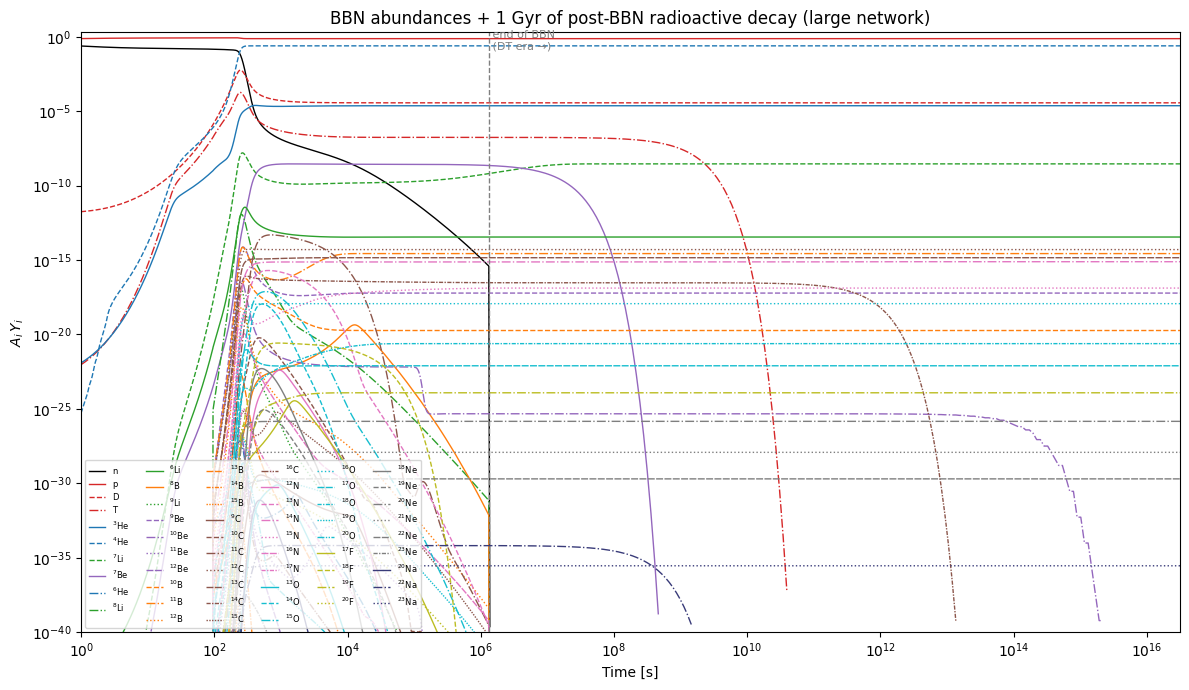

In [4]:
A = run.A                      # mass numbers, to plot A_i Y_i (per-baryon mass fraction)
styles = nuclide_styles(names) # element colour + isotope line style + label

FLOOR = 1e-40                  # plot floor: only drop curves below the y-axis limit
fig, ax = plt.subplots(figsize=(12, 7))
for s in names:
    color, ls, label = styles[s]
    vals = A[s] * Y_all[:, idx[s]]
    mask = vals > FLOOR
    if mask.any():
        ax.plot(t_all[mask], vals[mask], color=color, linestyle=ls, lw=1.0, label=label)

ax.axvline(t_end, color='grey', ls='--', lw=1.0)
ax.text(t_end, 3, ' end of BBN\n (DT era →)', va='top', fontsize=8, color='grey')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Time [s]'); ax.set_ylabel(r'$A_i\,Y_i$')
ax.set_xlim(1, t_all[-1]); ax.set_ylim(FLOOR, 2)
ax.legend(ncol=6, fontsize=6, loc='lower left')
ax.set_title('BBN abundances + 1 Gyr of post-BBN radioactive decay (large network)')
plt.tight_layout()
plt.show()

## Zoom on the decay "steps"

The clearest physics is the conversion of unstable parents into their daughters.
We plot the number-fraction `Y` (not `A Y`) of each parent/daughter pair and mark
the parent's half-life with a vertical line: the parent falls by a factor of 2 at
each `T½` past `t_end`, and the daughter rises by the matching amount.

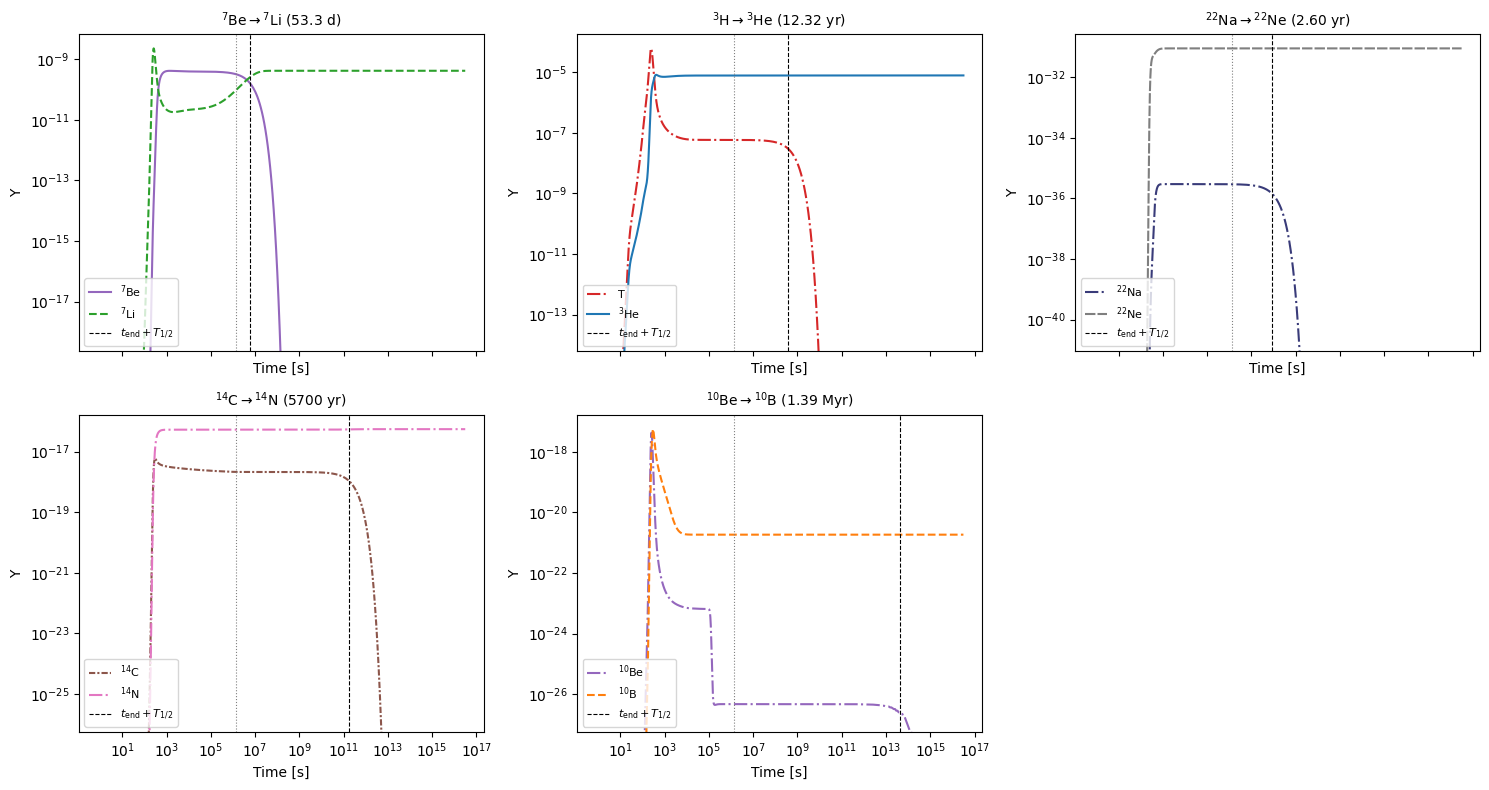

In [5]:
# (parent, daughter, half-life [s], panel title) -- half-lives from decays.txt.
pairs = [
    ('Be7', 'Li7', 4.604256e+06, r'$^7$Be$\to^7$Li (53.3 d)'),
    ('H3',  'He3', 3.887896e+08, r'$^3$H$\to^3$He (12.32 yr)'),
    ('Na22','Ne22',8.210797e+07, r'$^{22}$Na$\to^{22}$Ne (2.60 yr)'),
    ('C14', 'N14', 1.798745e+11, r'$^{14}$C$\to^{14}$N (5700 yr)'),
    ('Be10','B10', 4.376946e+13, r'$^{10}$Be$\to^{10}$B (1.39 Myr)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes = axes.ravel()
for ax, (par, dau, thalf, lab) in zip(axes, pairs):
    if par not in idx or dau not in idx:
        ax.set_visible(False)
        continue
    pc, pls, plab = styles[par]   # same element colour/isotope style as the big plot
    dc, dls, dlab = styles[dau]
    yp = Y_all[:, idx[par]]
    yd = Y_all[:, idx[dau]]
    ax.plot(t_all[yp > 0], yp[yp > 0], color=pc, linestyle=pls, label=plab)
    ax.plot(t_all[yd > 0], yd[yd > 0], color=dc, linestyle=dls, label=dlab)
    ax.axvline(t_end, color='grey', ls=':', lw=0.8)
    ax.axvline(t_end + thalf, color='k', ls='--', lw=0.8, label=r'$t_{\rm end}+T_{1/2}$')
    ax.set_xscale('log'); ax.set_yscale('log')
    # The parent decays to ~0 (matrix-exp underflow), so autoscale would blow
    # the y-range out to ~1e-280; clamp to ~10 decades below the peak so the
    # decay step stays readable.
    peak = max(yp.max(), yd.max())
    ax.set_ylim(peak * 1e-10, peak * 3.0)
    ax.set_title(lab, fontsize=10)
    ax.set_xlabel('Time [s]'); ax.set_ylabel('Y')
    ax.legend(fontsize=8, loc='lower left')
axes[-1].set_visible(False)   # only 5 pairs; hide the 6th panel
plt.tight_layout()
plt.show()

## Sanity check: baryon number is conserved through the DT era

The decay matrix `D` moves mass between nuclei (with daughters weighted by
`A_daughter / A_parent`), so $\sum_i A_i Y_i$ is conserved up to the tiny mass
carried off by emitted leptons/photons (bookkeeping pseudo-species, not in the
ODE state).  We expect drift well below 10⁻⁶.

In [6]:
A_vec = np.array([run.A[s] for s in names])
baryon = Y_all @ A_vec
rel_drift = np.max(np.abs(baryon - baryon[0])) / baryon[0]
print(f'max |Δ(Σ A_i Y_i)| / (Σ A_i Y_i) over the whole history = {rel_drift:.2e}')

max |Δ(Σ A_i Y_i)| / (Σ A_i Y_i) over the whole history = 1.86e-12
